In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

from math import pi, gcd
from qiskit import *
from qiskit import transpile
from qiskit.circuit import *
from qiskit.circuit.library import *
from qiskit.quantum_info.operators import Operator
from qiskit_aer import AerSimulator, StatevectorSimulator
from scipy import optimize, linalg
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

In [62]:
from scipy.stats import norm as gaussian

def van_der_corput(n_points, base=2):
    """Suite de Van der Corput en base `base` pour n_points points dans ]0,1["""
    sequence = []
    for i in range(1, n_points + 1):
        n, denominator = i, 1
        result = 0.0
        while n:
            denominator *= base
            n, remainder = divmod(n, base)
            result += remainder / denominator
        sequence.append(result)
    return np.array(sequence)

def rodeo_random(N_ancillas, phi_size, H, E, phi_init, T_max=10, type="random"):
    q = QuantumRegister(N_ancillas)
    phi = QuantumRegister(phi_size)
    cq = ClassicalRegister(N_ancillas)
    cphi = ClassicalRegister(phi_size)
    qc = QuantumCircuit(q, phi, cq, cphi)

    qc.initialize(phi_init, phi)

    if type == "random":
        ts = np.random.uniform(0, T_max, N_ancillas)
    elif type == "quantile":
        quantiles = np.arange(1, N_ancillas + 1) / (N_ancillas + 1)
        ts = gaussian.ppf(quantiles, loc=T_max / 2, scale=T_max / 4)
    elif type == "geometric":
        ts = np.geomspace(0.1, T_max, N_ancillas)
    elif type == "vdc":
        ts = van_der_corput(N_ancillas, base=2) * T_max
    elif type == "gaussian":
        ts = np.random.normal(loc=0, scale=T_max, size=N_ancillas)
    else:
        raise ValueError(f"Unknown type '{type}'. Use 'random', 'quantile', 'geometric', 'vdc' or 'gaussian'.")

    for i in range(N_ancillas):
        t = ts[i]
        qc.h(q[i])
        U = expm(-1j * H * t)
        U_gate = UnitaryGate(U, label="exp(-iHt)")
        cU_gate = U_gate.control(1)
        qc.append(cU_gate, [q[i]] + list(phi))
        qc.p(E * t, q[i])
        qc.h(q[i])
        qc.measure(q[i], cq[i])

    qc.measure(phi, cphi)

    simulator = AerSimulator()
    qc_t = transpile(qc, simulator)
    job = simulator.run(qc_t, shots=1000)
    result = job.result()
    counts = result.get_counts()
    return counts


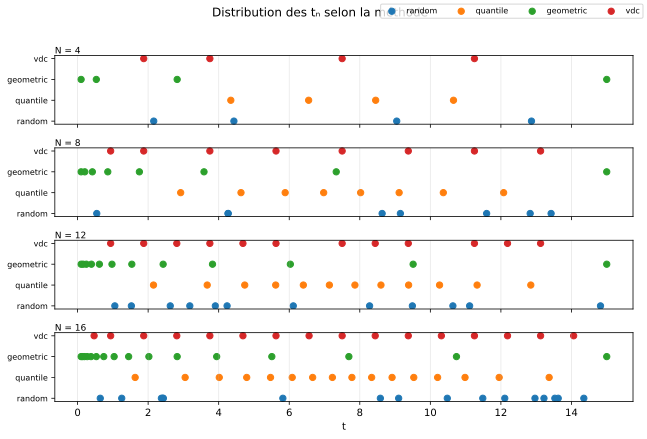

Van der Corput base 2, N=8 :
  n=1  binaire=0001  réfléchi=0.1000  valeur=0.5000  →  t=7.500
  n=2  binaire=0010  réfléchi=0.0100  valeur=0.2500  →  t=3.750
  n=3  binaire=0011  réfléchi=0.1100  valeur=0.7500  →  t=11.250
  n=4  binaire=0100  réfléchi=0.0010  valeur=0.1250  →  t=1.875
  n=5  binaire=0101  réfléchi=0.1010  valeur=0.6250  →  t=9.375
  n=6  binaire=0110  réfléchi=0.0110  valeur=0.3750  →  t=5.625
  n=7  binaire=0111  réfléchi=0.1110  valeur=0.8750  →  t=13.125
  n=8  binaire=1000  réfléchi=0.0001  valeur=0.0625  →  t=0.938


In [63]:
# Visualisation de la suite de Van der Corput vs les autres méthodes
# pour comprendre pourquoi elle évite les résonances

T_max = 15
Ns = [4, 8, 12, 16]

fig, axes = plt.subplots(len(Ns), 1, figsize=(9, 6), sharex=True)
methods = {
    "random":    ("tab:blue",   lambda N: np.sort(np.random.uniform(0, T_max, N))),
    "quantile":  ("tab:orange", lambda N: gaussian.ppf(np.arange(1,N+1)/(N+1), loc=T_max/2, scale=T_max/4)),
    "geometric": ("tab:green",  lambda N: np.geomspace(0.1, T_max, N)),
    "vdc":       ("tab:red",    lambda N: np.sort(van_der_corput(N, base=2) * T_max)),
}

for ax, N in zip(axes, Ns):
    for i, (label, (color, fn)) in enumerate(methods.items()):
        ts = fn(N)
        ax.scatter(ts, [i] * N, color=color, s=40, label=label if N == Ns[0] else "")
    ax.set_yticks(range(len(methods)))
    ax.set_yticklabels(list(methods.keys()), fontsize=8)
    ax.set_title(f"N = {N}", fontsize=9, loc='left', pad=2)
    ax.grid(axis='x', alpha=0.3)

axes[-1].set_xlabel("t")
fig.suptitle("Distribution des tₙ selon la méthode", y=1.01)
fig.legend(loc='upper right', ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

# Afficher les valeurs explicitement pour N=8 pour montrer la construction
print("Van der Corput base 2, N=8 :")
vdc8 = van_der_corput(8, base=2)
for i, v in enumerate(vdc8, 1):
    binary = format(i, '04b')
    reflected = binary[::-1]
    print(f"  n={i}  binaire={binary}  réfléchi=0.{reflected}  valeur={v:.4f}  →  t={v*T_max:.3f}")


In [64]:
# Simple example: 1-qubit Hamiltonian H = Z (Pauli Z)
# Eigenvalues: E = +1 (eigenstate |0⟩), E = -1 (eigenstate |1⟩)

H = np.array([[1, 0],
              [0, -1]], dtype=complex)

E_target = 1.0
N_ancillas = 3
phi_size = 1

# Start from an equal superposition |+⟩ = (|0⟩ + |1⟩)/√2
# The rodeo algorithm should project it onto |0⟩ (eigenstate of E=+1)
phi_init = np.array([1, 1]) / np.sqrt(2)

counts = rodeo_random(N_ancillas=N_ancillas, phi_size=phi_size, H=H, E=E_target,
                      phi_init=phi_init, T_max=10)

# Qiskit bitstring order (left to right): cphi | cq
# cphi is the last register added → leftmost phi_size bits
# cq is the first register added  → rightmost N_ancillas bits
success_counts = {k: v for k, v in counts.items() if k[-N_ancillas:] == '0' * N_ancillas}

total_shots = sum(counts.values())
success_shots = sum(success_counts.values())

print(f"Total shots:   {total_shots}")
print(f"Success shots (all ancillas = 0): {success_shots}")
print(f"Success rate:  {success_shots / total_shots:.2%}")
print()
print("Phi register outcomes after successful projection:")
for bitstring, count in sorted(success_counts.items(), key=lambda x: -x[1]):
    phi_bits = bitstring[:phi_size]  # leftmost bits = cphi
    print(f"  phi = |{phi_bits}⟩ : {count} shots")


Total shots:   1000
Success shots (all ancillas = 0): 521
Success rate:  52.10%

Phi register outcomes after successful projection:
  phi = |0⟩ : 511 shots
  phi = |1⟩ : 10 shots


In [65]:
# Hamiltonien diagonal : H = diag(1, 1, -1, -1)
# Eigenstates de valeur propre  1 : |00⟩, |01⟩
# Eigenstates de valeur propre -1 : |10⟩, |11⟩

H2 = np.diag([1, 1, -1, -1]).astype(complex)
E_target = 1.0

eigenvalues, eigenvectors = np.linalg.eigh(H2)
print("Eigenvalues:", eigenvalues)
print("Eigenspace E=1  → |00⟩, |01⟩")
print("Eigenspace E=-1 → |10⟩, |11⟩")

N_ancillas = 6
phi_size = 2
phi_init = np.ones(4) / 2.0   # superposition uniforme

counts = rodeo_random(N_ancillas=N_ancillas, phi_size=phi_size, H=H2, E=E_target,
                      phi_init=phi_init, T_max=15)

success_counts = {k: v for k, v in counts.items() if k[-N_ancillas:] == '0' * N_ancillas}
total_shots   = sum(counts.values())
success_shots = sum(success_counts.values())

correct = sum(v for k, v in success_counts.items() if k[:phi_size] in ('00', '01'))

print(f"\nTotal shots   : {total_shots}")
print(f"Succès        : {success_shots}  ({success_shots/total_shots:.1%})")
print(f"Dans E=1      : {correct}  ({correct/success_shots:.1%} des succès)")
print()
for bits in ['00', '01', '10', '11']:
    c = sum(v for k, v in success_counts.items() if k[:phi_size] == bits)
    print(f"  |{bits}⟩ : {c} shots")


Eigenvalues: [-1. -1.  1.  1.]
Eigenspace E=1  → |00⟩, |01⟩
Eigenspace E=-1 → |10⟩, |11⟩

Total shots   : 1000
Succès        : 491  (49.1%)
Dans E=1      : 490  (99.8% des succès)

  |00⟩ : 227 shots
  |01⟩ : 263 shots
  |10⟩ : 1 shots
  |11⟩ : 0 shots


In [ ]:
# "Triche" : calcul exact de l'état post-sélectionné par produit de matrices
# K_n = (I + e^{iEt_n} · e^{-iHt_n}) / 2

def rodeo_exact(N_ancillas, H, E, phi_init, T_max=10, type="random"):
    n = len(phi_init)
    I = np.eye(n, dtype=complex)

    if type == "random":
        ts = np.random.uniform(0, T_max, N_ancillas)
    elif type == "quantile":
        quantiles = np.arange(1, N_ancillas + 1) / (N_ancillas + 1)
        ts = gaussian.ppf(quantiles, loc=T_max / 2, scale=T_max / 4)
    elif type == "geometric":
        ts = np.geomspace(0.1, T_max, N_ancillas)
    elif type == "vdc":
        ts = van_der_corput(N_ancillas, base=2) * T_max
    elif type == "gaussian":
        ts = np.random.normal(loc=0, scale=T_max, size=N_ancillas)

    psi = phi_init.astype(complex).copy()
    for t in ts:
        K = (I + np.exp(1j * E * t) * expm(-1j * H * t)) / 2
        psi = K @ psi

    norm = np.linalg.norm(psi)
    if norm < 1e-12:
        return None, np.nan, np.nan
    psi /= norm

    E_mean = np.real(psi.conj() @ H @ psi)
    return psi, E_mean


# E_ref = eigenvalue le plus proche de E cible
E_ref = eigenvalues3[np.argmin(np.abs(eigenvalues3 - E_ground3))]
print(f"E cible = {E_ground3:.4f},  E_ref = {E_ref:.4f}")
print(f"Métrique : ⟨(H - E_ref)²⟩ = Var(H) + (⟨H⟩ - E_ref)²")
print(f"         → 0 ssi phi est l'eigenstate de E_ref")

phi_init3 = np.ones(8) / np.sqrt(8)
N_range = list(range(1, 20))
n_runs = 30

def metric(psi, H, E_ref):
    dH = H - E_ref * np.eye(len(H), dtype=complex)
    return np.real(psi.conj() @ dH @ dH @ psi)

results = {"random": [], "gaussian": [], "quantile": [], "geometric": [], "vdc": []}
for n in N_range:
    for t in results:
        vals = []
        for _ in range(n_runs):
            psi, _ = rodeo_exact(n, H3, E_ground3, phi_init3, T_max=15, type=t)
            vals.append(metric(psi, H3, E_ref) if psi is not None else np.nan)
        results[t].append(vals)

fig, ax = plt.subplots(figsize=(8, 4))
colors = {"random": "tab:blue", "gaussian": "tab:purple",
          "quantile": "tab:orange", "geometric": "tab:green", "vdc": "tab:red"}
for t in results:
    means = [np.nanmean(r) for r in results[t]]
    stds  = [np.nanstd(r)  for r in results[t]]
    ax.plot(N_range, means, marker='o', markersize=4, label=t, color=colors[t])
    ax.fill_between(N_range,
                    [m - s for m, s in zip(means, stds)],
                    [m + s for m, s in zip(means, stds)],
                    alpha=0.15, color=colors[t])

ax.axhline(0.0, color='gray', linestyle='--',
           label=f'idéal : phi = eigenstate de E_ref = {E_ref:.3f}')
ax.set_xlabel("N_ancillas")
ax.set_ylabel("⟨(H − E_ref)²⟩")
ax.set_title(f"Rodeo algorithm — Ising 3 qubits\n(T_max=15, 30 runs)")
ax.set_ylim(bottom=-0.05)
ax.legend(ncol=2)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# Ising 1D transverse field pour n qubits quelconque
# H = Σ_i Z_i Z_{i+1}  +  g Σ_i X_i  +  h Σ_i c_i Z_i
# c_i décroissant pour briser toutes les dégénérescences

def build_ising(n_qubits, g=0.7, h=0.4):
    I2 = np.eye(2, dtype=complex)
    X  = np.array([[0,1],[1,0]], dtype=complex)
    Z  = np.array([[1,0],[0,-1]], dtype=complex)
    N  = 2 ** n_qubits

    def op_on_qubit(gate, i, n):
        """gate agissant sur le qubit i dans un système de n qubits"""
        ops = [I2] * n
        ops[i] = gate
        result = ops[0]
        for o in ops[1:]:
            result = np.kron(result, o)
        return result

    H = np.zeros((N, N), dtype=complex)

    # ZZ interactions (voisins)
    for i in range(n_qubits - 1):
        ops = [I2] * n_qubits
        ops[i] = Z
        ops[i+1] = Z
        term = ops[0]
        for o in ops[1:]:
            term = np.kron(term, o)
        H += term

    # Champ transverse X
    for i in range(n_qubits):
        H += g * op_on_qubit(X, i, n_qubits)

    # Champ longitudinal Z asymétrique (coefficients décroissants)
    for i in range(n_qubits):
        c_i = 1.0 - 0.3 * i / max(n_qubits - 1, 1)
        H += h * c_i * op_on_qubit(Z, i, n_qubits)

    return H


# Vérification : 3 qubits doit donner le même spectre que H3
H_check = build_ising(3, g=0.7, h=0.4)
eigs_check = np.linalg.eigvalsh(H_check)
print("Spectre 3 qubits (build_ising) :", np.round(eigs_check, 4))
print("Spectre H3 (original)          :", np.round(eigenvalues3, 4))
print()
for n in [4, 5, 6]:
    eigs = np.linalg.eigvalsh(build_ising(n))
    print(f"{n} qubits : {len(eigs)} eigenvalues, E_ground = {eigs[0]:.4f}")


In [ ]:
# Même plot que précédemment pour 3, 4, 5, 6 qubits

N_range = list(range(1, 20))
n_runs  = 30
colors  = {"random": "tab:blue", "gaussian": "tab:purple",
           "quantile": "tab:orange", "geometric": "tab:green", "vdc": "tab:red"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)

for ax, n_qubits in zip(axes.flat, [3, 4, 5, 6]):
    H    = build_ising(n_qubits)
    eigs = np.linalg.eigvalsh(H)
    E_ground = eigs[0]
    E_ref    = eigs[np.argmin(np.abs(eigs - E_ground))]
    phi_init = np.ones(2**n_qubits) / np.sqrt(2**n_qubits)

    results = {"random": [], "gaussian": [], "quantile": [], "geometric": [], "vdc": []}
    for n in N_range:
        for t in results:
            vals = []
            for _ in range(n_runs):
                psi, _ = rodeo_exact(n, H, E_ground, phi_init, T_max=15, type=t)
                vals.append(metric(psi, H, E_ref) if psi is not None else np.nan)
            results[t].append(vals)

    for t in results:
        means = [np.nanmean(r) for r in results[t]]
        stds  = [np.nanstd(r)  for r in results[t]]
        ax.plot(N_range, means, marker='o', markersize=3, label=t, color=colors[t])
        ax.fill_between(N_range,
                        [m - s for m, s in zip(means, stds)],
                        [m + s for m, s in zip(means, stds)],
                        alpha=0.15, color=colors[t])

    ax.axhline(0.0, color='gray', linestyle='--')
    ax.set_title(f"{n_qubits} qubits — {2**n_qubits} eigenstates  (E_ref={E_ref:.3f})")
    ax.set_xlabel("N_ancillas")
    ax.set_ylabel("⟨(H − E_ref)²⟩")
    ax.set_ylim(bottom=-0.05)
    ax.grid(True, alpha=0.4)

axes.flat[0].legend(ncol=2, fontsize=8)
fig.suptitle("Rodeo algorithm — scaling en nombre de qubits\n(Ising 1D, T_max=15, 30 runs)",
             fontsize=12)
plt.tight_layout()
plt.show()
